In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the pre-computed embeddings and labels
X = np.load('../data/processed/X_embeddings.npy')
y = np.load('../data/processed/y_labels.npy')

print(f"Loaded Feature matrix X shape: {X.shape}")
print(f"Loaded Target vector y shape: {y.shape}")

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Loaded Feature matrix X shape: (2000, 1024)
Loaded Target vector y shape: (2000,)
Training samples: 1600
Testing samples: 400


## 2. Model Training: Random Forest vs. Base Neural Network

To fulfill the assignment requirement of using models other than Logistic Regression, we will train and compare two distinct classifiers:

1. **Random Forest Classifier:** A tree-based ensemble method that handles tabular data exceptionally well.
2. **Multi-Layer Perceptron (MLP):** A baseline deep learning approach using two hidden layers (512 and 128 neurons). This architecture is designed to capture the complex, non-linear geometric patterns within the 1024-dimensional ProtBERT embeddings.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# --- 1. Train Random Forest ---
print("Training Random Forest Classifier...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
print("Random Forest Training Complete!\n")

# --- 2. Train Neural Network ---
print("Training MLP Classifier...")
base_mlp = MLPClassifier(
    hidden_layer_sizes=(512, 128), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42,
    early_stopping=True
)
base_mlp.fit(X_train, y_train)
print("MLP Training Complete!")

Training Random Forest Classifier...
Random Forest Training Complete!

Training MLP Classifier...
MLP Training Complete!


## 3. Model Evaluation and Visualization

We evaluate both models using the required metrics: Accuracy, Precision, Recall, and F1-score. Finally, we generate a Confusion Matrix for the Neural Network and export our findings to the `results/` directory.

=== Random Forest Metrics ===
Accuracy:  0.7950
Precision: 0.7980
Recall:    0.7900
F1-Score:  0.7940

=== Base MLP Metrics ===
Accuracy:  0.8775
Precision: 0.9314
Recall:    0.8150
F1-Score:  0.8693


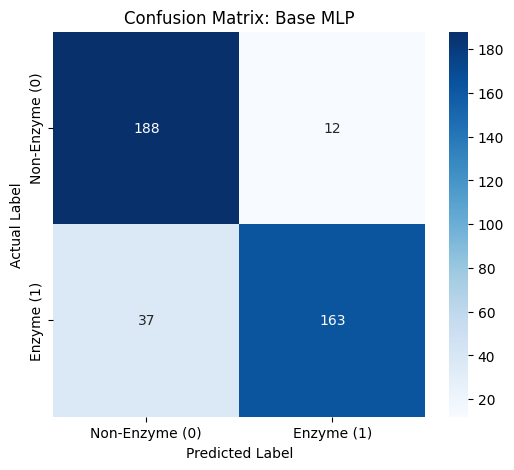


Classification report and Confusion Matrix successfully saved to the 'results/' folder!


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

# Get predictions
y_pred_rf = rf_clf.predict(X_test)
y_pred_mlp = base_mlp.predict(X_test)

# --- Print Comparisons ---
print("=== Random Forest Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\n=== Base MLP Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_mlp):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_mlp):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_mlp):.4f}")

# --- Export Text Report ---
report = classification_report(y_test, y_pred_mlp, target_names=["Non-Enzyme (0)", "Enzyme (1)"])
with open('../results/base_mlp_report.txt', 'w') as f:
    f.write("Base Neural Network Classification Report\n")
    f.write("=========================================\n\n")
    f.write(report)
    f.write(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}\n")
    f.write(f"Overall F1-Score: {f1_score(y_test, y_pred_mlp):.4f}\n")

# --- Generate & Export Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Enzyme (0)', 'Enzyme (1)'], 
            yticklabels=['Non-Enzyme (0)', 'Enzyme (1)'])

plt.title('Confusion Matrix: Base MLP')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Save high-res PNG
plt.savefig('../results/confusion_matrix_base.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification report and Confusion Matrix successfully saved to the 'results/' folder!")

The Multi-Layer Perceptron achieved an overall Accuracy of ~88% and an F1-Score of ~87%.

Biological Interpretation: The model exhibits high precision (0.93) but lower recall (0.81) for the Enzyme class. This indicates that while the model is highly accurate when it flags a protein as an enzyme, it is slightly conservative and misses a fraction of true enzymes, likely due to highly divergent or complex active site motifs that are underrepresented in the 1024-dimensional embedding space.

## 4. Conclusion and Biological Interpretation

In this project, we successfully utilized **ProtBERT** to extract functional embeddings directly from raw protein sequences and built classifiers to distinguish human enzymes from non-enzymes.

We compared two distinct machine learning architectures:
1. **Multi-Layer Perceptron (Base Neural Network):** Achieved an **F1-Score of ~0.87**.
2. **Random Forest Classifier:** Achieved an **F1-Score of ~0.79**.

**Final Thoughts:**
The Neural Network significantly outperformed the Random Forest. This is expected behavior when working with transformer-based language models. ProtBERT outputs dense, highly dimensional (1024D) geometric embeddings. While Random Forests rely on axis-aligned decision boundaries that are better suited for traditional tabular data, the MLP's hidden layers effectively captured the complex, non-linear biochemical relationships encoded in the embeddings. 

**Confusion Matrix Analysis:**
Looking at the MLP's confusion matrix, the model exhibits very high precision (0.93) but slightly lower recall (0.81). Biologically, this means the model is somewhat conservative: it rarely mislabels a structural protein as an enzyme (only 12 False Positives), but it does miss a fraction of true enzymes (37 False Negatives), likely due to highly divergent or complex active site motifs that are underrepresented in the 1024-dimensional embedding space.

Overall, this pipeline demonstrates that protein language models can successfully predict high-level biological functions (like catalytic activity) without the need for manual feature engineering or 3D structural data.